In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

### 1. Revenue & Growth
**Goal:** Assess the financial health of the service and its growth rate.

**Queries:** `daily_revenue_growth.sql` · `daily_arpu_arppu_aov.sql` · `new_vs_returning_users_revenue.sql`

daily revenue + cumulative total + day-over-day growth rate

In [2]:
df_revenue_growth = pd.read_csv('data/01-revenue/daily-revenue-growth-table.csv')

In [3]:
# parse dates: format='%d/%m/%y' prevents Jan/Sep mix-up
df_revenue_growth.date = pd.to_datetime(df_revenue_growth['date'], format='%d/%m/%y')
df_revenue_growth['month_day'] = df_revenue_growth['date'].dt.strftime('%d.%m')

In [4]:
df_revenue_growth['revenue_1M'] = df_revenue_growth.revenue / 1000000
df_revenue_growth['total_revenue_1M'] = df_revenue_growth.total_revenue / 1000000

In [5]:
df_daily_revenue = pd.read_csv('data/01-revenue/daily-revenue-growth-table.csv')

In [6]:
df_daily_revenue['date'] = pd.to_datetime(df_daily_revenue['date'], format='%d/%m/%y')
df_daily_revenue['month_day'] = df_daily_revenue['date'].dt.strftime('%d.%m')

In [7]:
# fill NaN in first row — no previous day to compare against
df_daily_revenue['revenue_change'] = df_daily_revenue['revenue_change'].fillna(0)

In [8]:
df_daily_revenue

,date,revenue,total_revenue,revenue_change,month_day
0,2022-08-24,49924,49924,0.00,24.08
1,2022-08-25,430860,480784,763.03,25.08
2,2022-08-26,534766,1015550,24.12,26.08
3,2022-08-27,817053,1832603,52.79,27.08
4,2022-08-28,1133370,2965973,38.71,28.08
5,2022-08-29,1279891,4245864,12.93,29.08
6,2022-08-30,1279377,5525241,-0.04,30.08
7,2022-08-31,1312720,6837961,2.61,31.08
8,2022-09-01,1406101,8244062,7.11,01.09
9,2022-09-02,1907107,10151169,35.63,02.09


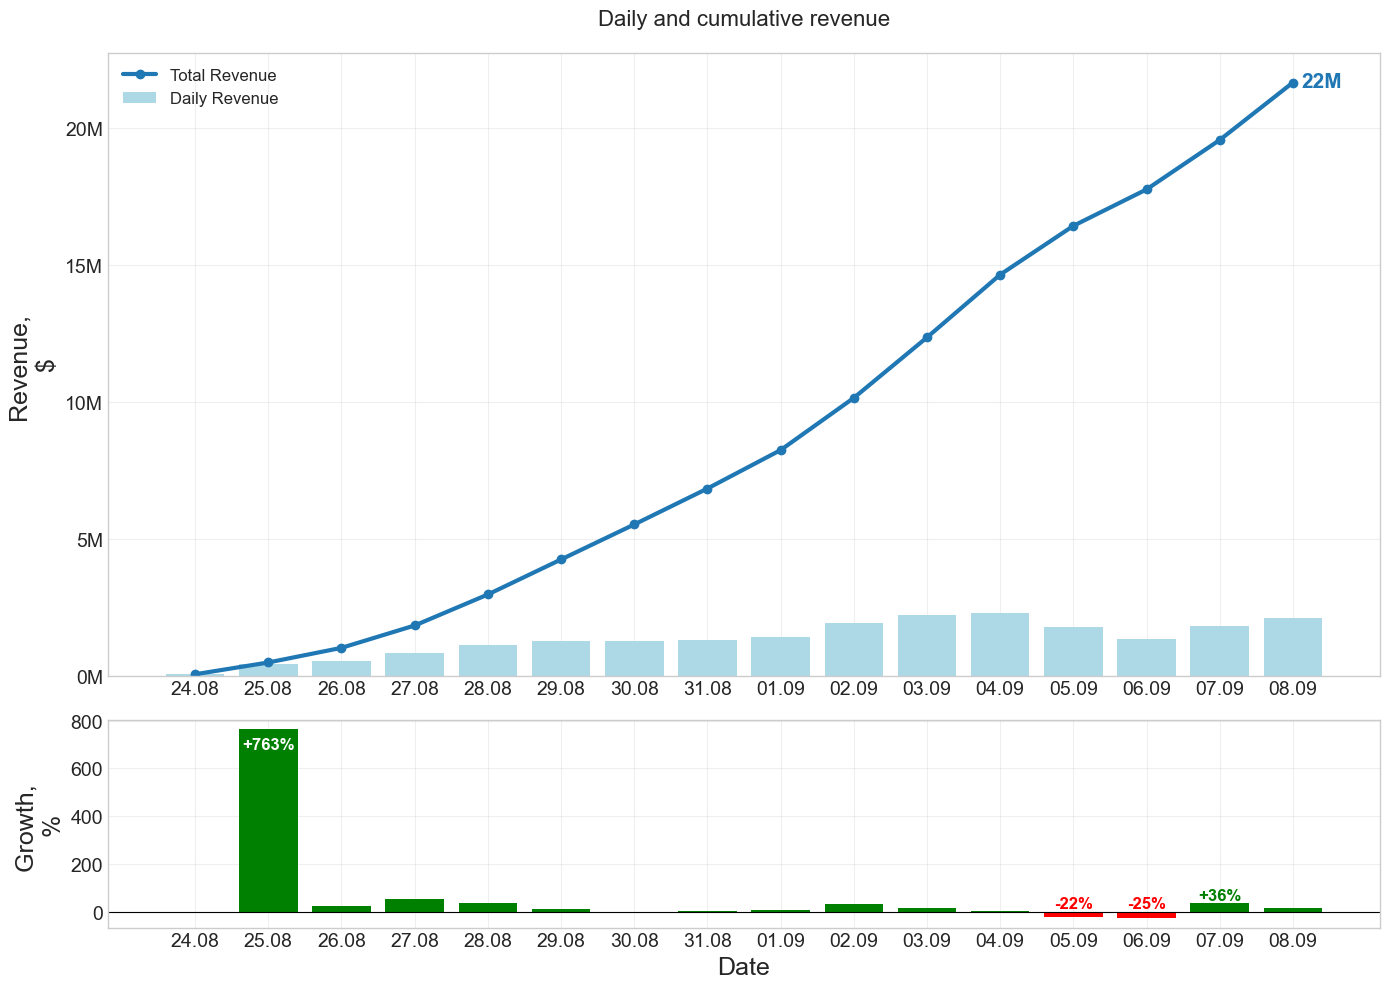

In [174]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df_daily_revenue['month_day'], df_daily_revenue['total_revenue']/1000000,
         marker='o', linewidth=3, label='Total Revenue')
ax1.bar(df_daily_revenue['month_day'], df_daily_revenue['revenue']/1000000,
        label='Daily Revenue', color='lightblue')



val_ = df_daily_revenue['total_revenue'].iloc[15] /1000000
ax1.annotate(f'{val_:.0f}M', xy=(15.4, 21.7), ha='center', va='center',
             color='#1f77b4', fontweight='bold', fontsize=15)




ax1.set_title('Daily and cumulative revenue', fontsize=16, pad=20)
ax1.set_ylabel('Revenue, \n$', fontsize=18)
ax1.legend(loc='upper left', fontsize=12)
ax1.grid(True, linestyle='-', alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.yaxis.set_major_formatter('{x:,.0f}M')

colors = ['green' if x > 0 else 'red' for x in df_daily_revenue['revenue_change']]
ax2.bar(df_daily_revenue['month_day'], df_daily_revenue['revenue_change'], color=colors)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Date', fontsize=18)
ax2.set_ylabel('Growth, \n%', fontsize=18)

# annotate the spike on day 2
val = df_daily_revenue['revenue_change'].iloc[1]
ax2.annotate(f'+{val:.0f}%', xy=(1.0, 700), ha='center', va='center',
             color='white', fontweight='bold', fontsize=12)
val1 = df_daily_revenue['revenue_change'].iloc[12]
ax2.annotate(f'{val1:.0f}%', 
             xy=(12.0, 35),            
             ha='center', va='center', 
             color='red', fontweight='bold', fontsize=12)

val2 = df_daily_revenue['revenue_change'].iloc[13]
ax2.annotate(f'{val2:.0f}%', 
             xy=(13.0, 35),            
             ha='center', va='center', 
             color='red', fontweight='bold', fontsize=12)

val3 = df_daily_revenue['revenue_change'].iloc[14]
ax2.annotate(f'+{val3:.0f}%', 
             xy=(14.0, 70),            
             ha='center', va='center', 
             color='green', fontweight='bold', fontsize=12)

ax2.locator_params(axis='y', nbins=5)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** Revenue grew **42×** over 16 days ($50k → $2.1M/day). The dip on Sep 5–6 (−22%, −25%) reflects lower weekend demand from office workers, followed by a strong Monday rebound (+36% Sep 7). Growth came entirely from more users and more orders — not higher spend per order.

ARPU / ARPPU / AOV per day

In [131]:
df_arpu = pd.read_csv('data/01-revenue/daily-arpu-arppu-aov-table.csv')

In [132]:
df_arpu['date'] = pd.to_datetime(df_arpu['date'], format='%d/%m/%y')
df_arpu['month_day'] = df_arpu['date'].dt.strftime('%d.%m')

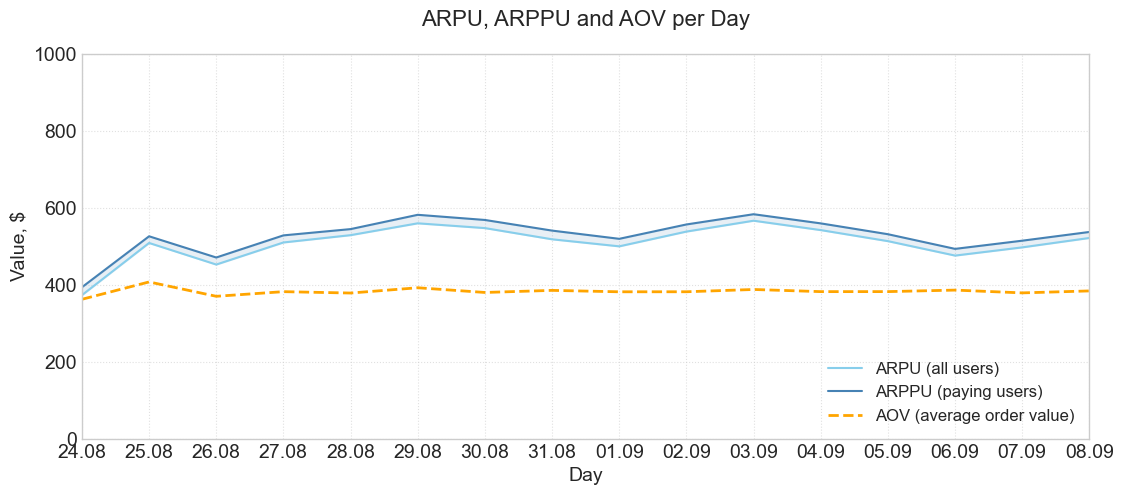

In [133]:
plt.figure(figsize=(13, 5))

plt.plot(df_arpu['month_day'], df_arpu['arpu'], label='ARPU (all users)', color='skyblue')
plt.plot(df_arpu['month_day'], df_arpu['arppu'], label='ARPPU (paying users)', color='steelblue')
plt.plot(df_arpu['month_day'], df_arpu['aov'], label='AOV (average order value)',
         color='orange', linestyle='--', linewidth=2)

# shaded area = users who were active but placed no order ('silent users')
plt.fill_between(df_arpu['month_day'], df_arpu['arpu'], df_arpu['arppu'],
                 alpha=0.12, color='steelblue')

plt.title('ARPU, ARPPU and AOV per Day', fontsize=16, pad=20)
plt.xlabel('Day', fontsize=14)
plt.ylabel('Value, $', fontsize=14)
plt.ylim(0, 1000)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gca().margins(x=0)
plt.show()

**Insight:** The narrow gap between ARPU and ARPPU shows **high conversion** — most active users placed at least one order. The shaded area between the lines represents 'silent users' who opened the app but didn't buy. AOV stayed flat at ~$383: revenue growth came from volume, not from higher spend per order.

Running (cumulative) versions of ARPU / ARPPU / AOV

In [134]:
df_run_ARPU = pd.read_csv('data/01-revenue/running-arpu-arppu-aov_table.csv')

In [135]:
df_run_ARPU['date'] = pd.to_datetime(df_run_ARPU['date'], format='%d/%m/%y')
df_run_ARPU['month_day'] = df_run_ARPU['date'].dt.strftime('%d.%m')

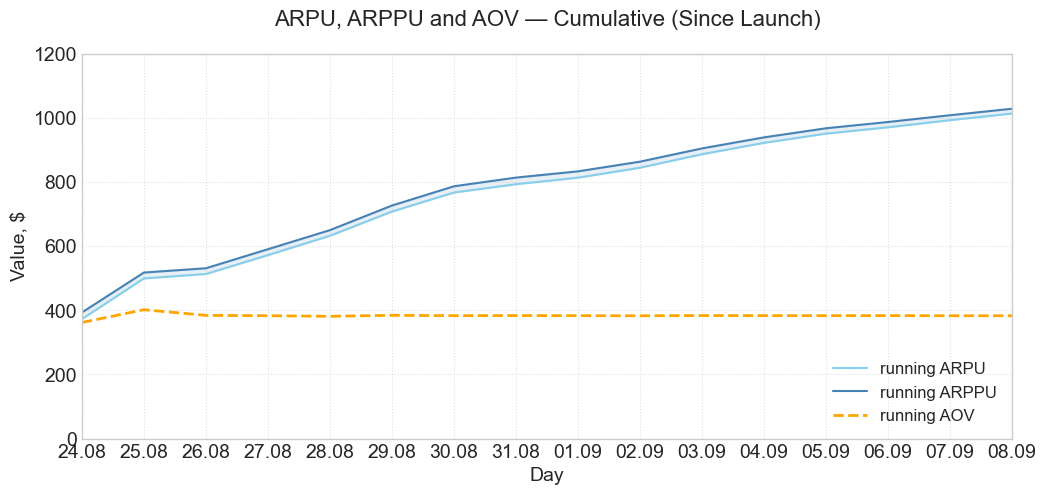

In [136]:
plt.figure(figsize=(12, 5))

plt.plot(df_run_ARPU['month_day'], df_run_ARPU['running_arpu'], label='running ARPU', color='skyblue')
plt.plot(df_run_ARPU['month_day'], df_run_ARPU['running_arppu'], label='running ARPPU', color='steelblue')
plt.plot(df_run_ARPU['month_day'], df_run_ARPU['running_aov'], label='running AOV',
         color='orange', linestyle='--', linewidth=2)

# shaded area shows the gap between all users and paying users, cumulative
plt.fill_between(df_run_ARPU['month_day'],
                 df_run_ARPU['running_arpu'],
                 df_run_ARPU['running_arppu'],
                 alpha=0.12, color='steelblue')

plt.title('ARPU, ARPPU and AOV — Cumulative (Since Launch)', fontsize=16, pad=20)
plt.xlabel('Day', fontsize=14)
plt.ylabel('Value, $', fontsize=14)
plt.ylim(0, 1200)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gca().margins(x=0)
plt.show()

**Insight:** Running ARPPU grew from $393 to $1028 — each paying user brought $1028 in total revenue over the period. Running AOV stabilised at ~$383 by Day 3, confirming that average order size didn't change.

Breakdown by day of week

In [137]:
df_week_ARPU = pd.read_csv('data/01-revenue/weekday-arpu-arppu-aov_table.csv')

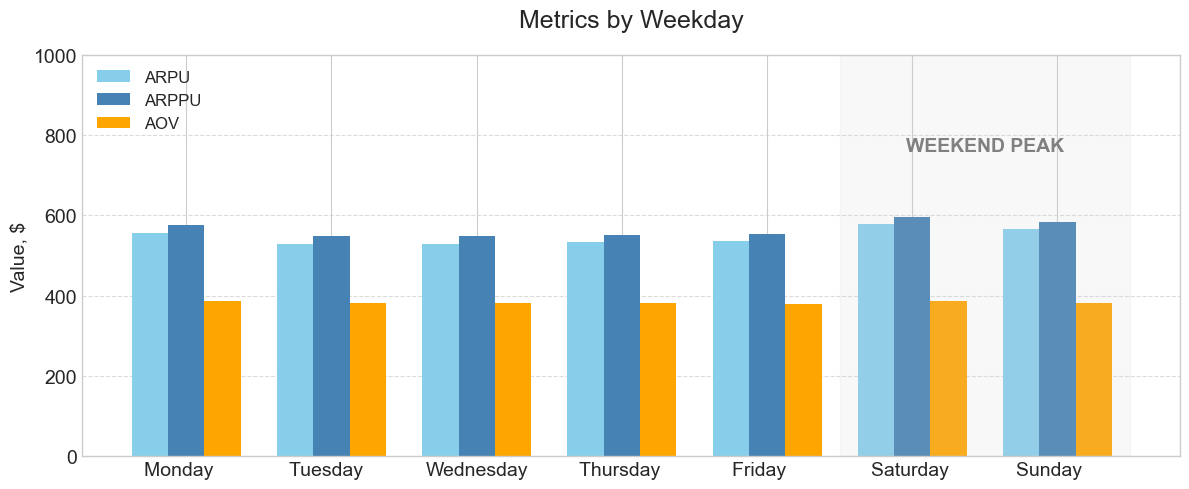

In [138]:
x = np.arange(len(df_week_ARPU['weekday']))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(x - width, df_week_ARPU['arpu'],  width, label='ARPU',  color='skyblue')
ax.bar(x,          df_week_ARPU['arppu'], width, label='ARPPU', color='steelblue')
ax.bar(x + width,  df_week_ARPU['aov'],  width, label='AOV',   color='orange')

# highlight the weekend zone
ax.axvspan(4.5, 6.5, color='lightgrey', alpha=0.15)
ax.text(5.5, max(df_week_ARPU['arppu']) + 165, 'WEEKEND PEAK',
        color='grey', fontweight='bold', fontsize=14, ha='center')

ax.set_title('Metrics by Weekday', fontsize=18, pad=20)
ax.set_xticks(x)
ax.set_xticklabels(df_week_ARPU['weekday'])
ax.set_ylabel('Value, $', fontsize=14)
ax.set_ylim(0, 1000)
ax.legend(loc='upper left', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

**Insight:** Saturday shows the highest ARPU ($579) and ARPPU ($595). Weekdays are fairly similar (~$529–$556). Weekend is the natural peak — useful for scheduling promotions and courier capacity.

Revenue split between new and returning users

In [139]:
df_new_return = pd.read_csv('data/01-revenue/new-vs-returning-users-revenue-table.csv')

In [140]:
df_new_return['date'] = pd.to_datetime(df_new_return['date'], format='%d/%m/%y')
df_new_return['month_day'] = df_new_return['date'].dt.strftime('%d.%m')

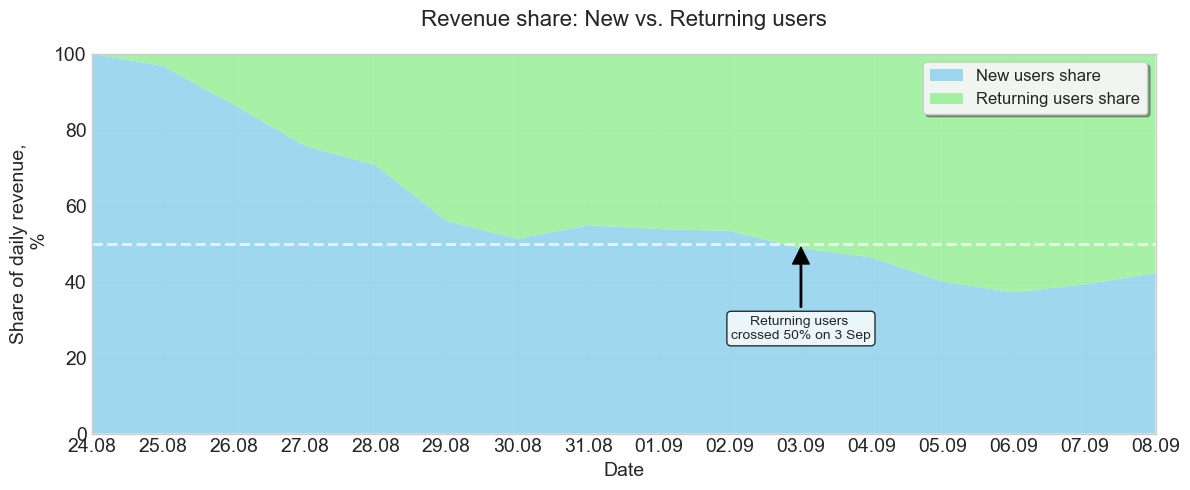

In [141]:
plt.figure(figsize=(12, 5))
plt.stackplot(df_new_return['month_day'],
              df_new_return['new_users_revenue_share'],
              df_new_return['old_users_revenue_share'],
              labels=['New users share', 'Returning users share'],
              colors=['skyblue', 'lightgreen'], alpha=0.8)

# 50% reference line — the crossover point
plt.axhline(y=50, color='white', linestyle='--', linewidth=2, alpha=0.7)
plt.annotate('Returning users \ncrossed 50% on 3 Sep',
             xy=(10, 50), xytext=(10, 25),
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='black', lw=1, alpha=0.8),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             horizontalalignment='center')

plt.title('Revenue share: New vs. Returning users', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Share of daily revenue,\n %', fontsize=14)
plt.ylim(0, 100)
plt.legend(loc='upper right', fontsize='large', frameon=True, framealpha=0.9, shadow=True)
plt.grid(alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gca().margins(x=0)
plt.tight_layout()
plt.show()

**Insight:** On Aug 24, 100% of revenue came from new users. By Sep 3, returning users crossed 50% of daily revenue. By Sep 8 their share reached **58%** — a healthy sign that a loyal base is forming.

### 2. Marketing Efficiency

**Goal:** Evaluate the return on investment for two ad campaigns that both launched on September 1, 2022, each with a budget of 250,000 u.e.

- **Campaign 1:** YouTube influencer (cooking channel) → 171 new registered users
- **Campaign 2:** Targeted social media ads → 236 new registered users

CAC per campaign and ROI over the full observation period

In [24]:
df_cac = pd.read_csv('data/02-marketing/campaign_cac-table.csv')
df_roi = pd.read_csv('data/02-marketing/campaign-roi-table.csv')

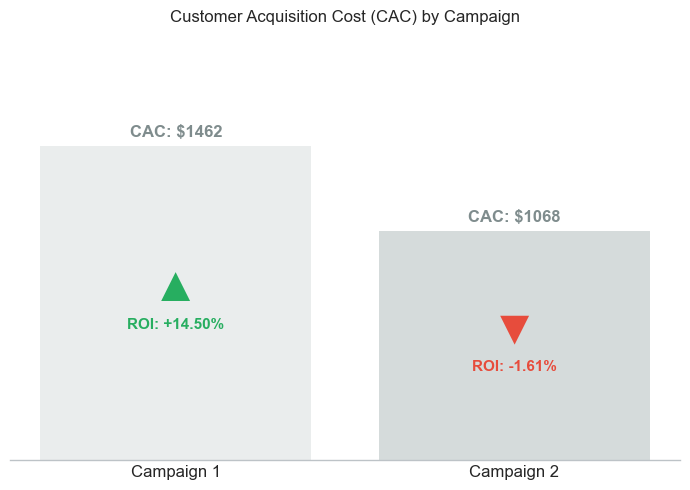

In [25]:
plt.figure(figsize=(7, 5))
bars = plt.bar(df_cac['ads_campaign'], df_cac['cac'], color=['#EAEDED', '#D5DBDB'])
plt.title('Customer Acquisition Cost (CAC) by Campaign', fontsize=12)
plt.grid(False)
plt.ylim(0, 2000)

for i, bar in enumerate(bars):
    xc = bar.get_x() + bar.get_width() / 2
    y_center = bar.get_height() / 2
    roi = df_roi['roi'][i]

    # colour and arrow based on ROI sign
    color  = '#27ae60' if roi > 0 else '#e74c3c'
    marker = '▲' if roi > 0 else '▼'

    plt.text(xc, y_center + 60,  marker, color=color, fontsize=30, ha='center', va='center')
    plt.text(xc, y_center - 120, f'ROI: {roi:+.2f}%',
             color=color, fontweight='bold', ha='center', fontsize=11)
    plt.text(xc, bar.get_height() + 40, f'CAC: ${df_cac["cac"][i]:.0f}',
             ha='center', color='#7f8c8d', fontsize=12, fontweight='bold')

ax = plt.gca()
ax.get_yaxis().set_visible(False)
for sp in ['top', 'right', 'left']:
    ax.spines[sp].set_visible(False)
ax.spines['bottom'].set_linewidth(1)
ax.spines['bottom'].set_color('#BDC3C7')
plt.tick_params(axis='x', which='both', bottom=False, labelsize=12)
plt.tight_layout()
plt.show()

**Insight:** Campaign 2 attracted more users (236 vs 171) at a lower CAC ($1,068 vs $1,462), but produced a **negative ROI of −1.6%**. The problem is not order size — it's retention: Campaign 2 users stop returning far sooner.

Average order value per campaign (first week)

In [26]:
df_avg_check = pd.read_csv('data/02-marketing/campaign-avg-check-table.csv')
df_avg_check = df_avg_check.sort_values('ads_campaign')

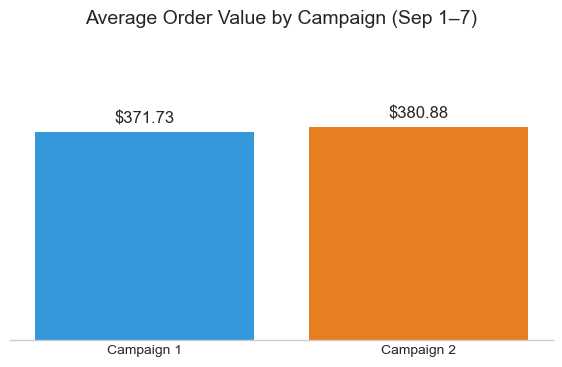

In [29]:
df_avg_check = df_avg_check.sort_values('ads_campaign')
plt.figure(figsize=(7,4))

bars1=plt.bar(df_avg_check['ads_campaign'],df_avg_check["avg_check"], color=['#3498db', '#e67e22'])
plt.title('Average Order Value by Campaign (Sep 1–7)', fontsize=14)
plt.ylabel('Value, USD')
plt.grid(False) 
plt.ylim(0, 550)

plt.yticks([]) 
plt.ylabel('')


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)



ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('#CCCCCC')

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 10,
             f'${height:.2f}', ha='center', va='bottom', fontsize=12)

**Insight:** Campaign 2 avg check ($380.88) is even slightly higher than Campaign 1 ($371.73). This confirms the ROI gap is **not** about how much users spend per order — it's about how often they come back.

Daily cumulative ARPPU vs CAC to find the payback day

In [30]:
df_cumulative_arppu_cac = pd.read_csv('data/02-marketing/campaign-cumulative-arppu-vs-cac-table.csv')
campaign_1 = df_cumulative_arppu_cac[df_cumulative_arppu_cac['ads_campaign'] == 'Campaign 1']
campaign_2 = df_cumulative_arppu_cac[df_cumulative_arppu_cac['ads_campaign'] == 'Campaign 2']

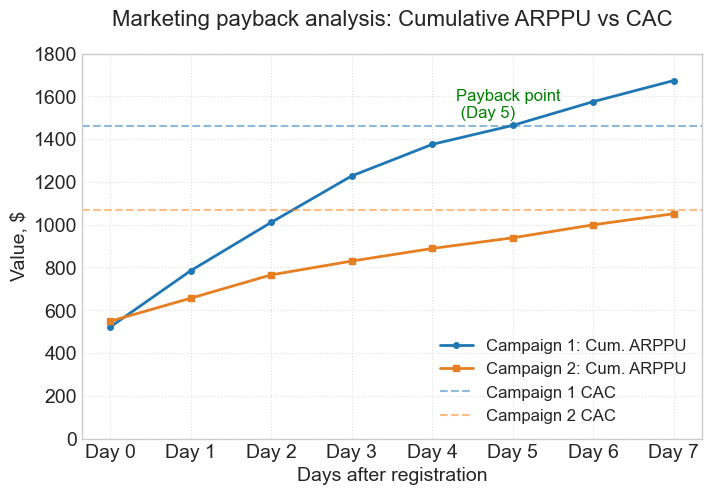

In [98]:
plt.figure(figsize=(8, 5))
plt.plot(campaign_1['day'], campaign_1['cumulative_arppu'],
         label='Campaign 1: Cum. ARPPU', marker='o', markersize=4, linewidth=2)
plt.plot(campaign_2['day'], campaign_2['cumulative_arppu'],
         label='Campaign 2: Cum. ARPPU', color='#e67e22', marker='s', markersize=4, linewidth=2)

# dashed lines = CAC threshold — campaign is profitable when the curve crosses it
plt.axhline(y=1461.99, color='#1f77b4', linestyle='--', alpha=0.5, label='Campaign 1 CAC')
plt.axhline(y=1068.38, color='#ff7f0e', linestyle='--', alpha=0.5, label='Campaign 2 CAC')

plt.annotate('Payback point\n (Day 5)', xy=(5, 1463), xytext=(4.3, 1500),
             fontsize=12, color='green')

plt.title('Marketing payback analysis: Cumulative ARPPU vs CAC', fontsize=16, pad=20)
plt.xlabel('Days after registration', fontsize=14)
plt.ylabel('Value, $', fontsize=14)
plt.ylim(0, 1800)
plt.xticks(campaign_2['day'])
plt.legend(loc='lower right', fontsize=12, frameon=False)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

**Insight:** Campaign 1 reached payback on **Day 5** — cumulative ARPPU crossed the CAC line. Campaign 2 never reached payback in 8 days: on Day 7 it was still $17 short ($1,051 vs CAC $1,068). Recommendation: redirect budget to YouTube/content-driven channels.

## Block 3 — Retention & Engagement

**Goal:** Measure how well the product retains users over time and understand daily usage patterns.

Cohort retention by day for all users

In [36]:
df_cohort_retention = pd.read_csv('data/03-retention/cohort-retention-by-day-table.csv')

df_cohort_retention['start_date'] = pd.to_datetime(
    df_cohort_retention['start_date'], format='%d/%m/%y')
df_cohort_retention = df_cohort_retention.sort_values('start_date')

df_cohort_retention['date_label'] = df_cohort_retention['start_date'].dt.strftime('%d.%m')
df_cohort_retention['retention_pct'] = df_cohort_retention['retention'] * 100

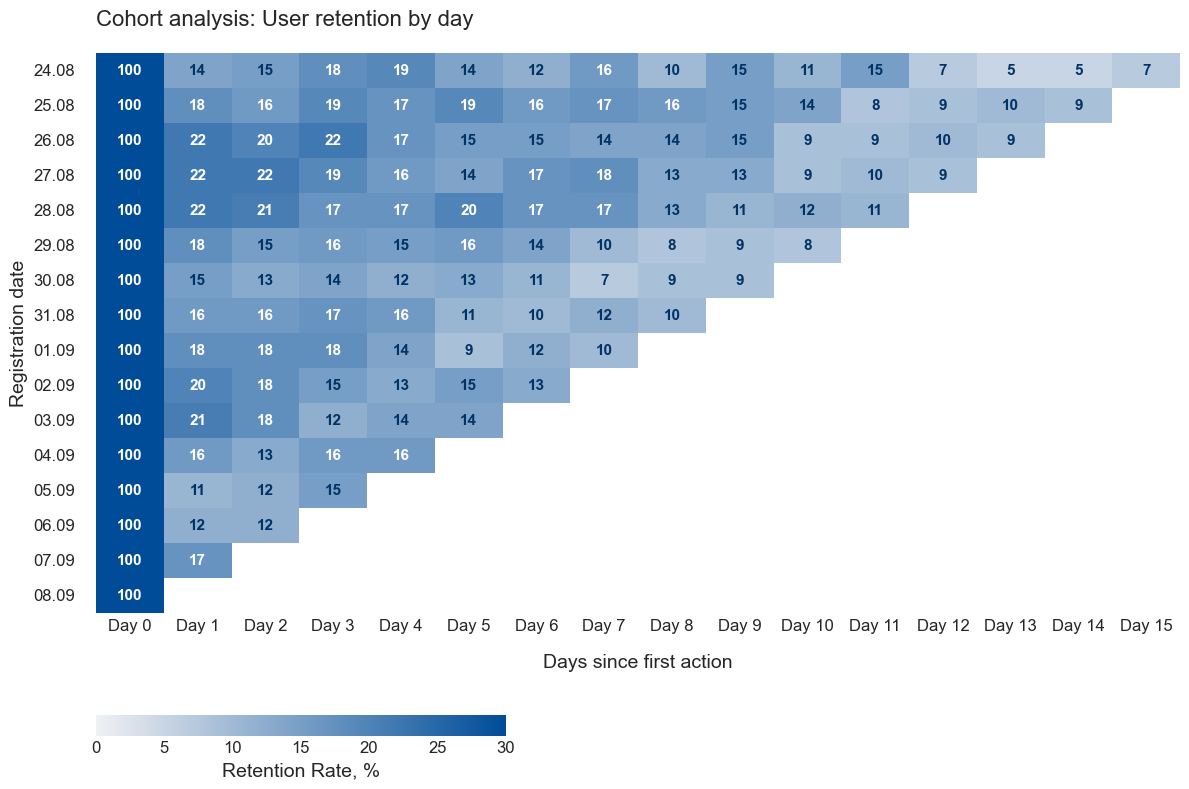

In [41]:

retention_pivot = df_cohort_retention.pivot(index='date_label', columns='day_number', values='retention_pct')


ordered_labels = df_cohort_retention['date_label'].unique()
retention_pivot = retention_pivot.reindex(ordered_labels)


retention_pivot.columns = [f'Day {int(c)}' for c in retention_pivot.columns]


plt.figure(figsize=(12, 8))


cmap_custom = sns.light_palette("#004c99", as_cmap=True)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] # Можно заменить на 'Verdana' или 'Tahoma'


ax = sns.heatmap(retention_pivot, 
            annot=True,         
            fmt=".0f",           

            annot_kws={'fontweight': 'bold', 'fontsize': 11},            
            cmap=cmap_custom,
            linewidths=0,      
            vmin=0,
            vmax=30,
            cbar_kws={
                     'label': 'Retention Rate (%)', 
                     'orientation': 'horizontal',
                     'pad': 0.15,    
                     'fraction': 0.03,  
                     'shrink': 0.8,   
                     'anchor': (0.0, 0.5) 
                 })


for text in ax.texts:
    val = float(text.get_text())
    if val > 15:          
        text.set_color('white')
    else:                 
        text.set_color('#003366') 


ax.collections[0].colorbar.ax.tick_params(labelsize=12) 

ax.collections[0].colorbar.set_label('Retention Rate, %', size=14)

plt.title('Cohort analysis: User retention by day', fontsize=16, pad=20, loc='left')
plt.xlabel('Days since first action', fontsize=14, labelpad=15)
plt.ylabel('Registration date', fontsize=14)
plt.tick_params(axis='both',which='major',labelsize=12)
plt.yticks(rotation=0)
plt.gca().tick_params(axis='y', pad=15)
plt.grid(False)

sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.savefig('retention_final_report.png', dpi=300)
plt.show()

**Insight:** Day 1 retention is 12–22% across all cohorts — typical for a young service in rapid acquisition mode. A stable core of ~10–12% remains active after 1–2 weeks. This loyal segment is worth targeting with retention mechanics (second-order discounts, push notifications).

Day 1 and Day 7 retention compared between Campaign 1 and Campaign 2

In [44]:
df_com_retention = pd.read_csv('data/03-retention/campaign_retention_day1_day7-table.csv')
df_com_retention['day_label'] = 'Day ' + df_com_retention['day_number'].astype(int).astype(str)

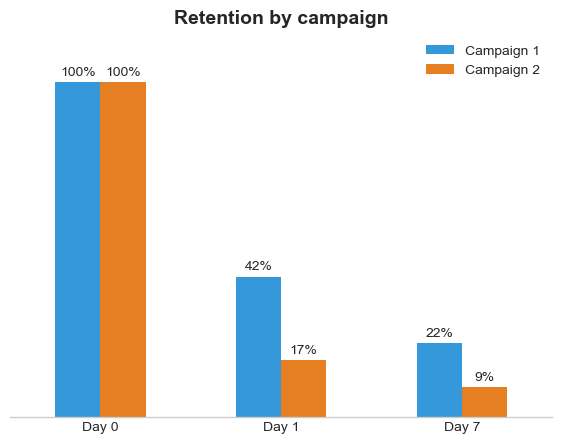

In [48]:

pivot_df = df_com_retention.pivot(index='day_label', columns='ads_campaign', values='retention')
pivot_df = pivot_df * 100 


ax = pivot_df.plot(kind='bar', figsize=(7, 5), color=['#3498db', '#e67e22'], rot=0)

# Оформление
plt.title('Retention by campaign', fontsize=14, fontweight='bold')
plt.ylabel('Retention (%)')
plt.xlabel('')

plt.ylim(0, 115)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.get_yaxis().set_visible(False)


for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%', (p.get_x() + p.get_width()/2, p.get_height() + 2), ha='center')
ax.grid(False)
plt.legend(frameon=False)
plt.show()

**Insight:** Day 1 retention — Campaign 1: **42%**, Campaign 2: **17%** (2.5× gap). Day 7: 22% vs 9%. This directly explains the ROI difference — YouTube users return far more often, generating more lifetime revenue despite a similar average order value.

Share of users placing 1 order vs 2+ orders per day

In [49]:
df_daily_intens = pd.read_csv('data/03-retention/daily-order-intensity-table.csv')

df_daily_intens['date'] = pd.to_datetime(df_daily_intens['date'], format='%d/%m/%y')
df_daily_intens['month_day'] = df_daily_intens['date'].dt.strftime('%d.%m')

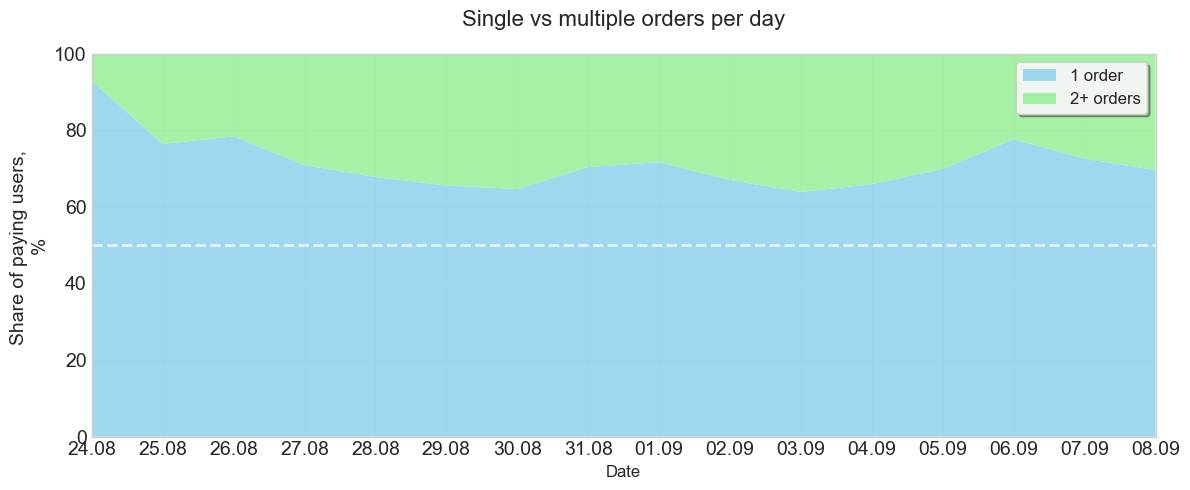

In [97]:
plt.figure(figsize=(12, 5))
plt.stackplot(df_daily_intens['month_day'],
              df_daily_intens['single_order_users_share'],
              df_daily_intens['several_orders_users_share'],
              labels=['1 order', '2+ orders'],
              colors=['skyblue', 'lightgreen'], alpha=0.8)

plt.axhline(y=50, color='white', linestyle='--', linewidth=2, alpha=0.7)

plt.title('Single vs multiple orders per day', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Share of paying users, \n%', fontsize=14)
plt.ylim(0, 100)
plt.legend(loc='upper right', fontsize='large', frameon=True, framealpha=0.9, shadow=True)
plt.grid(alpha=0.3)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.gca().margins(x=0)
plt.tight_layout()
plt.show()

**Insight:** The share of users placing 2+ orders per day grew from ~7% to ~30% — the service is becoming a **daily habit** for a growing segment.

## Block 4 — Operational Metrics

**Goal:** Identify cost dynamics, track audience growth, and monitor supply–demand balance as the service scales.

Share of first-ever orders and new-user orders in total daily volume

In [52]:
df_order_share = pd.read_csv('data/04-operations/daily-first-orders-share-table.csv')
df_order_share['date'] = pd.to_datetime(df_order_share['date'], format='%d/%m/%y')
df_order_share['month_day'] = df_order_share['date'].dt.strftime('%d.%m')

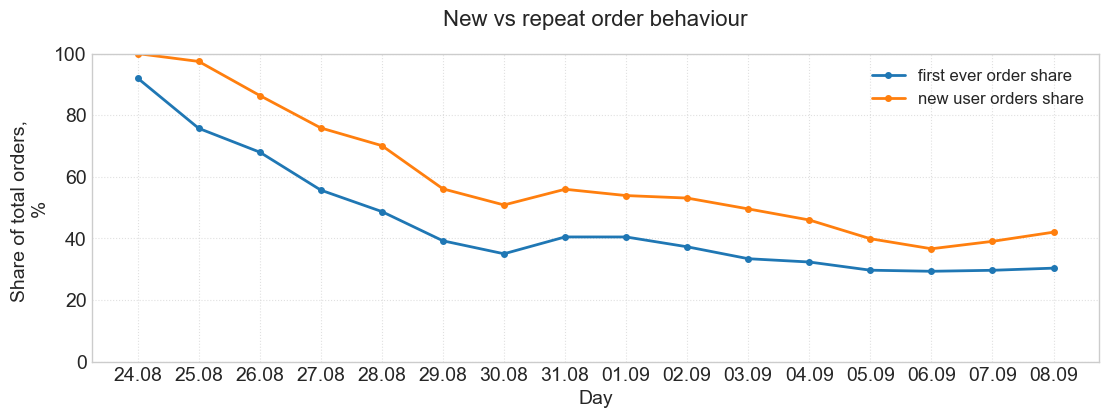

In [96]:
plt.figure(figsize=(13, 4))
plt.plot(df_order_share['month_day'], df_order_share['first_orders_share'],
         label='first ever order share', marker='o', markersize=4, linewidth=2)
plt.plot(df_order_share['month_day'], df_order_share['new_users_orders_share'],
         label='new user orders share', marker='o', markersize=4, linewidth=2)

plt.title('New vs repeat order behaviour', fontsize=16, pad=20)
plt.xlabel('Day', fontsize=14)
plt.ylabel('Share of total orders, \n%', fontsize=14)
plt.ylim(0, 100)
plt.legend(loc='upper right', fontsize=12, frameon=False)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

**Insight:** On Aug 24, 92% of all orders were first-ever orders. By Sep 8 this fell to 30% — 70% of orders now come from returning users. The platform is maturing and building a repeat-purchase base.

Daily paying users vs active couriers relative to cumulative totals

In [54]:
df_user_cour = pd.read_csv('data/04-operations/daily_active_users_couriers-table.csv')
df_user_cour['date'] = pd.to_datetime(df_user_cour['date'], format='%d/%m/%y')
df_user_cour['month_day'] = df_user_cour['date'].dt.strftime('%d.%m')

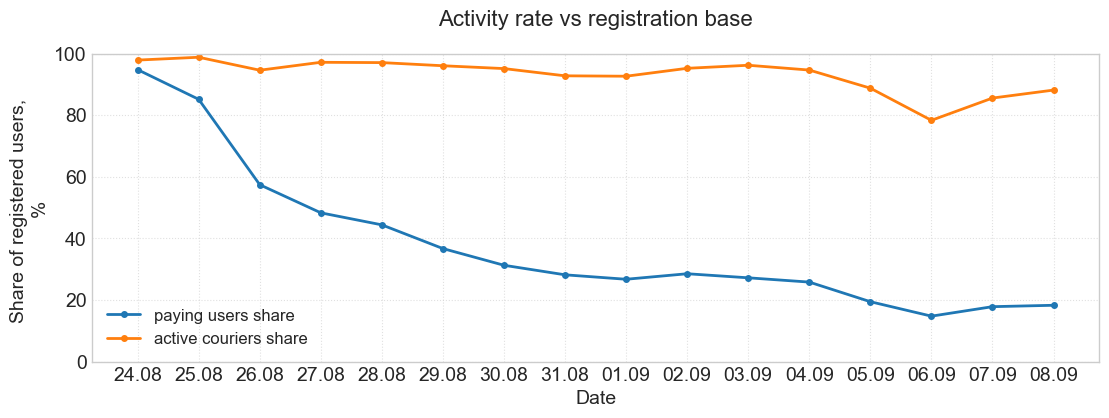

In [95]:
plt.figure(figsize=(13, 4))
plt.plot(df_user_cour['month_day'], df_user_cour['paying_users_share'],
         label='paying users share', marker='o', markersize=4, linewidth=2)
plt.plot(df_user_cour['month_day'], df_user_cour['active_couriers_share'],
         label='active couriers share', marker='o', markersize=4, linewidth=2)

plt.title('Activity rate vs registration base', fontsize=16, pad=20)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Share of registered users, \n%', fontsize=14)
plt.ylim(0, 100)
plt.legend(loc='lower left', fontsize=12, frameon=False)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.show()

**Insight:** Active couriers stayed at 78–99% of registered couriers throughout — excellent utilisation with no supply shortfall. Paying users' share of the registered base declines as the cumulative base grows faster than daily activity (normal dilution effect).

Daily and cumulative growth rates for users and couriers

In [58]:
df_cour_growth = pd.read_csv('data/04-operations/user-courier-growth-rates-table.csv')
df_cour_growth['date'] = pd.to_datetime(df_cour_growth['date'], format='%d/%m/%y')
df_cour_growth['month_day'] = df_cour_growth['date'].dt.strftime('%d.%m')
df_cour_growth = df_cour_growth.fillna(0)  # Day 1 has no previous day

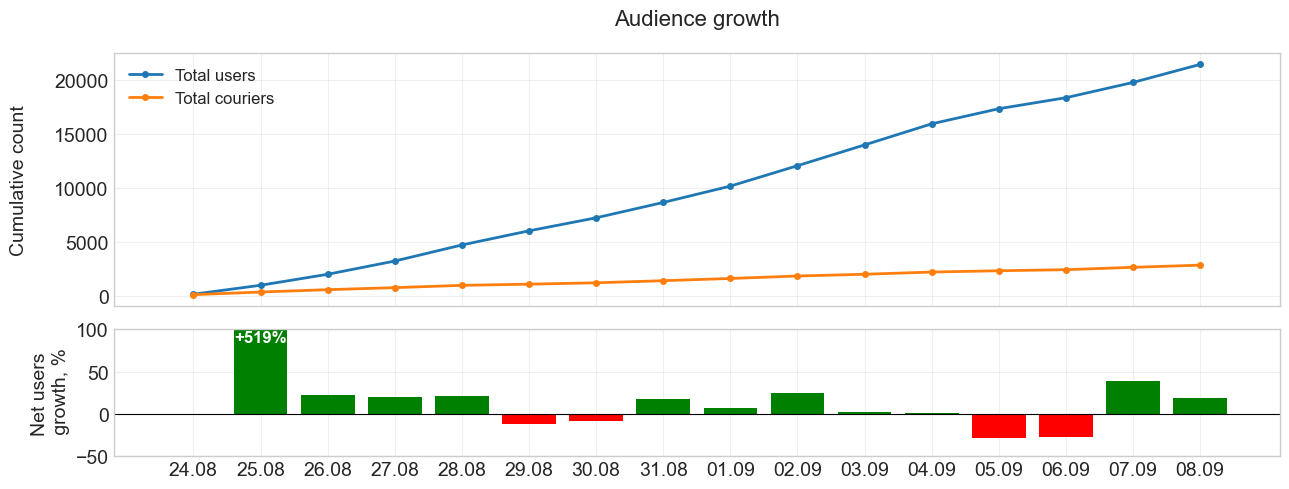

In [144]:
x = range(len(df_cour_growth))
dates = df_cour_growth['month_day']

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True,
                               gridspec_kw={'height_ratios': [2, 1]})

ax1.plot(x, df_cour_growth['total_users'], label='Total users', marker='o', markersize=4, linewidth=2)
ax1.plot(x, df_cour_growth['total_couriers'], label='Total couriers', marker='o', markersize=4, linewidth=2)

ax1.set_title('Audience growth', fontsize=16, pad=20)
ax1.set_ylabel('Cumulative count\n', fontsize=14)
ax1.legend(loc='upper left', fontsize=12, frameon=False)
ax1.grid(True, linestyle='-', alpha=0.3)

ax1.tick_params(axis='both', which='major', labelsize=14)
plt.setp(ax1.get_xticklabels(), visible=False)

colors = ['green' if x > 0 else 'red' for x in df_cour_growth['new_users_change']]
ax2.bar(x, df_cour_growth['new_users_change'], color=colors, width=0.8)
ax2.set_ylim(-50, 100)
ax2.axhline(0, color='black', linewidth=0.8)
ax2.grid(True, linestyle='-', alpha=0.3)
ax2.set_ylabel('Net users\n growth, %', fontsize=14)

# day 2 spike clipped at 100 — annotate real value
val = df_cour_growth['new_users_change'].iloc[1]
ax2.annotate(f'+{val:.0f}%', xy=(1.0, 90),
             ha='center', va='center', color='white', fontweight='bold', fontsize=12)

plt.xticks(x, dates, rotation=0)
ax2.tick_params(axis='both', which='major', labelsize=14)
plt.tight_layout()
plt.show()

**Insight:** New user growth peaked at +519% on Day 2 and decelerated to single digits by Sep 8 — organic acquisition channels are saturating. Couriers grew proportionally to users throughout, confirming no supply–demand imbalance.

Revenue contribution by product

In [64]:
df_prod_rev = pd.read_csv('data/04-operations/product-revenue-share-table.csv')

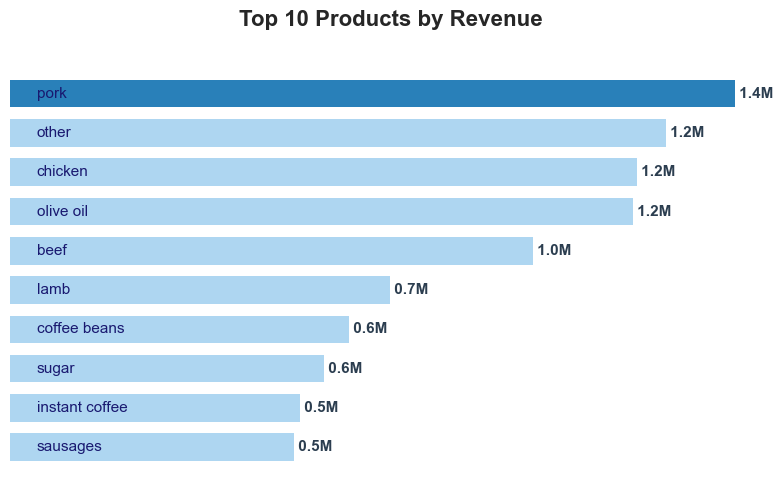

In [65]:
plt.figure(figsize=(8, 5))
top_names   = df_prod_rev['product_name'].head(10).str.lower().values
top_revenue = (df_prod_rev['revenue'].head(10) / 1_000_000).values

# first bar darker — emphasise the top product
colors = ['#2980b9'] + ['#aed6f1'] * 9

plt.barh(top_names, top_revenue, color=colors, height=0.7)
plt.gca().invert_yaxis()  # top-1 appears at the top

for i, v in enumerate(top_revenue):
    plt.text(0.05, i, f'{top_names[i]}',
             va='center', ha='left', color='midnightblue', fontweight='light', fontsize=11)
    plt.text(v, i, f' {v:.1f}M',
             va='center', ha='left', color='#2c3e50', fontweight='bold', fontsize=11)

plt.title('Top 10 Products by Revenue', fontsize=16, pad=25, fontweight='bold')
plt.yticks([])
plt.xticks([])
plt.xlabel('')
for sp in ['top', 'right', 'left', 'bottom']:
    plt.gca().spines[sp].set_visible(False)
plt.tight_layout()
plt.show()

**Insight:** Top products are meat (pork 6.2%, chicken 5.4%, beef 4.5%) and olive oil (5.4%). Products below 0.5% each are grouped as 'Other' (5.6%) — a long tail typical for grocery delivery assortments.

Daily P&L including revenue, variable and fixed costs, VAT, gross profit and gross margin

In [66]:
df_profit = pd.read_csv('data/04-operations/daily_gross_profit-table.csv')
df_profit['date'] = pd.to_datetime(df_profit['date'], format='%d/%m/%y')
df_profit['month_day'] = df_profit['date'].dt.strftime('%d.%m')

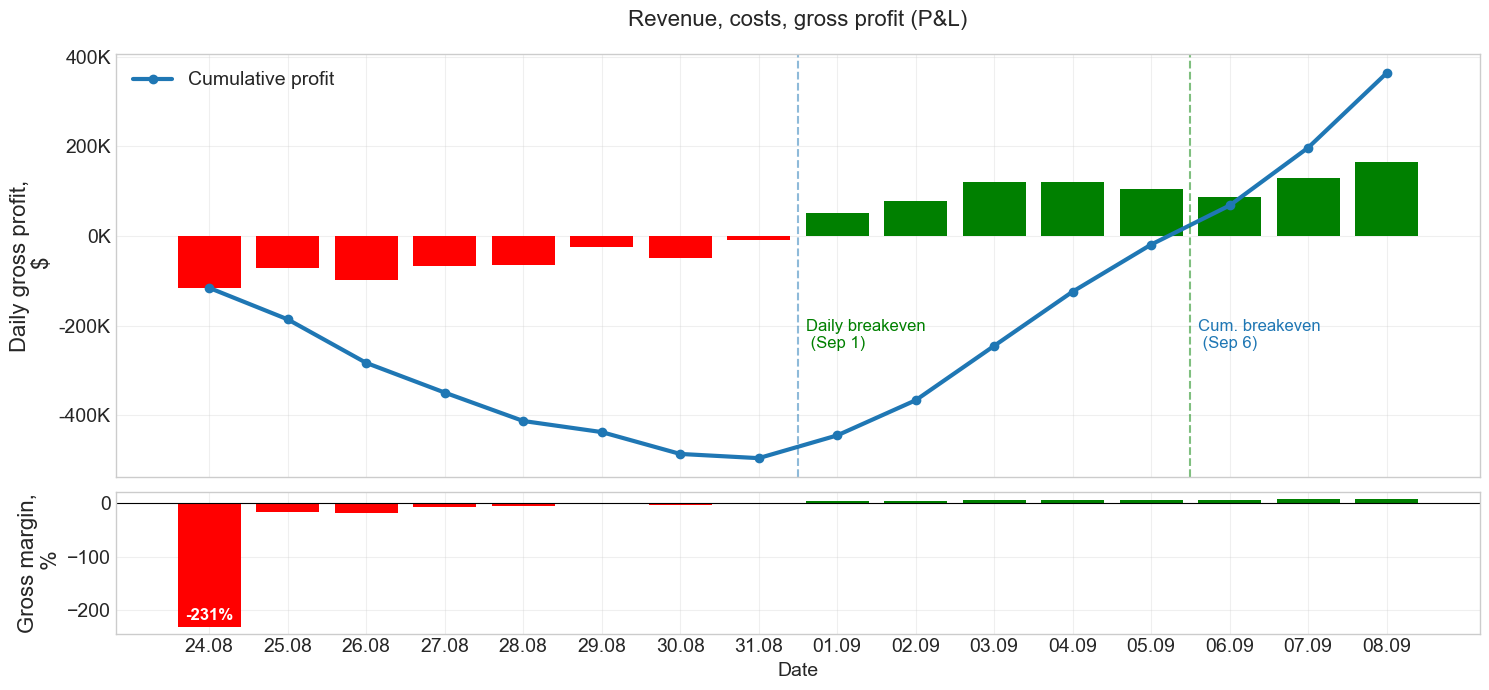

In [93]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 7),
                               gridspec_kw={'height_ratios': [3, 1]})

ax1.plot(df_profit['month_day'], df_profit['total_gross_profit']/1000,
         marker='o', linewidth=3, label='Cumulative profit')
colors = ['green' if x > 0 else 'red' for x in df_profit['gross_profit']]
ax1.bar(df_profit['month_day'], df_profit['gross_profit']/1000, color=colors)

ax1.set_title('Revenue, costs, gross profit (P&L)', fontsize=16, pad=20)
ax1.set_ylabel('Daily gross profit,\n $', fontsize=16)
ax1.legend(loc='upper left', fontsize=14)
ax1.grid(True, linestyle='-', alpha=0.3)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.yaxis.set_major_formatter('{x:,.0f}K')

plt.setp(ax1.get_xticklabels(), visible=False)

# breakeven markers
ax1.axvline(x=7.5, color='#1f77b4', linestyle='--', alpha=0.5)
ax1.axvline(x=12.5, color='green', linestyle='--', alpha=0.5)
ax1.annotate('Daily breakeven\n (Sep 1)', xy=(0, 0), xytext=(7.6, -250), fontsize=12, color='green')
ax1.annotate('Cum. breakeven\n (Sep 6)', xy=(0, 0), xytext=(12.6, -250), fontsize=12, color='#1f77b4')

# bottom panel: daily gross margin %
colors = ['green' if x > 0 else 'red' for x in df_profit['gross_profit_ratio']]
ax2.bar(df_profit['month_day'], df_profit['gross_profit_ratio'], color=colors)

# annotate first and last margin values
ax2.annotate(f"{df_profit['gross_profit_ratio'].iloc[0]:.0f}%",
             xy=(0.0, -210), ha='center', va='center',
             color='white', fontweight='bold', fontsize=12)
ax2.annotate(f"+{df_profit['gross_profit_ratio'].iloc[15]:.0f}%",
             xy=(15.0, 25), ha='center', va='center',
             color='green', fontweight='bold', fontsize=14)

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Date', fontsize=14)
ax2.set_ylabel('Gross margin,\n %', fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)
ax2.grid(True, linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:** The service ran at a loss for the first 8 days — fixed warehouse costs ($120k/day) exceeded revenue at low order volumes. Daily profit turned positive on **Sep 1**. Cumulative profit crossed zero on **Sep 6** — the overall breakeven point. Gross margin improved from −231% (Day 1) to +7.9% (Day 16).

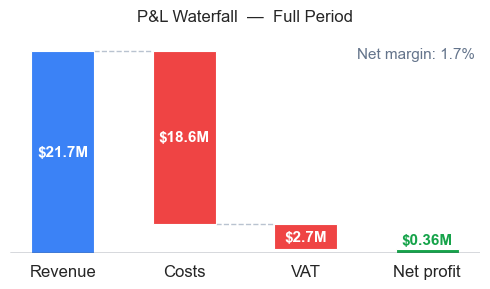

In [86]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
 

final_row = df_profit.iloc[-1]
total_revenue = final_row['total_revenue']
total_costs   = final_row['total_costs']
total_tax     = final_row['total_tax']
net_profit    = final_row['total_gross_profit']
 

 
labels  = ['Revenue', 'Costs', 'VAT', 'Net profit']
amounts = [total_revenue, -total_costs, -total_tax, net_profit]
 
BLUE  = '#3b82f6'
RED   = '#ef4444'
GREEN = '#16a34a'
GREY  = '#94a3b8'
colors = [BLUE, RED, RED, GREEN]
 
# ── waterfall───────────────────────────────────────────
# Revenue starts at 0.
# Costs start at the top of the Revenue column and go down.
# VAT starts at the bottom of the Costs column and goes even lower.
# Net profit is a separate total column that always starts at 0.
bases = [0, 0, 0, 0]
running = 0
for i in range(3):
    bases[i] = running if amounts[i] >= 0 else running + amounts[i]
    running += amounts[i]
bases[3] = 0  
heights = [abs(a) for a in amounts]
 
# ── figure ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 3))

 
x  = np.arange(len(labels))
bw = 0.52
 
ax.bar(x, heights, bottom=bases, color=colors,
       width=bw, zorder=3, edgecolor='white', linewidth=0.8)
 
#── connecting lines ───────────────────────────────────────────────────
# Show the running total after each deduction.
# Revenue → Costs: line at the total_revenue level (top of Revenue)
# Costs → VAT:    line at the revenue - costs level (bottom of Costs = top of VAT base)
running_totals = [
    total_revenue,
    total_revenue - total_costs,
]
for i, y_line in enumerate(running_totals):
    ax.plot([x[i] + bw/2, x[i+1] - bw/2],
            [y_line, y_line],
            color=GREY, linestyle='--', linewidth=1, alpha=0.65, zorder=2)
 
# ── text ───────────────────────────────────────────────────────
# > 6% of revenu → white, inside
# other → outside
scale = total_revenue
 
def fmt(v):
    m = abs(v) / 1e6
    return f'${m:.2f}M' if m < 1 else f'${m:.1f}M'
 
for i in range(len(labels)):
    h     = heights[i]
    b     = bases[i]
    mid_y = b + h / 2
    top_y = b + h
    txt   = fmt(amounts[i])
    big   = h > scale * 0.06
 
    if i == 3:
        # Net profit 
        ax.text(x[i], top_y + scale * 0.012, txt,
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color=GREEN)
    elif big:
       
        ax.text(x[i], mid_y, txt,
                ha='center', va='center',
                fontsize=11, fontweight='bold', color='white')
    else:
       
        ax.text(x[i], b - scale * 0.012, txt,
                ha='center', va='top',
                fontsize=11, fontweight='bold', color=colors[i])
 



plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)
 
# ── axis X ─────────────────────────────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.tick_params(axis='x', length=0, pad=8)
 
# ── Zero ine ─────────────────────────────────────────────────────────
ax.axhline(0, color='#334155', linewidth=1, zorder=4)
 

 
# ── net margin ─────────────────────────────────────────────────────
margin = net_profit / total_revenue * 100
ax.text(0.99, 0.97, f'Net margin: {margin:.1f}%',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=11, color='#64748b')
 
 
# ── titel
ax.set_title('P&L Waterfall  —  Full Period',
             fontsize=12, pad=14)

ax.set_yticklabels([])

ax.grid(False)
 
plt.tight_layout()

plt.show()
 

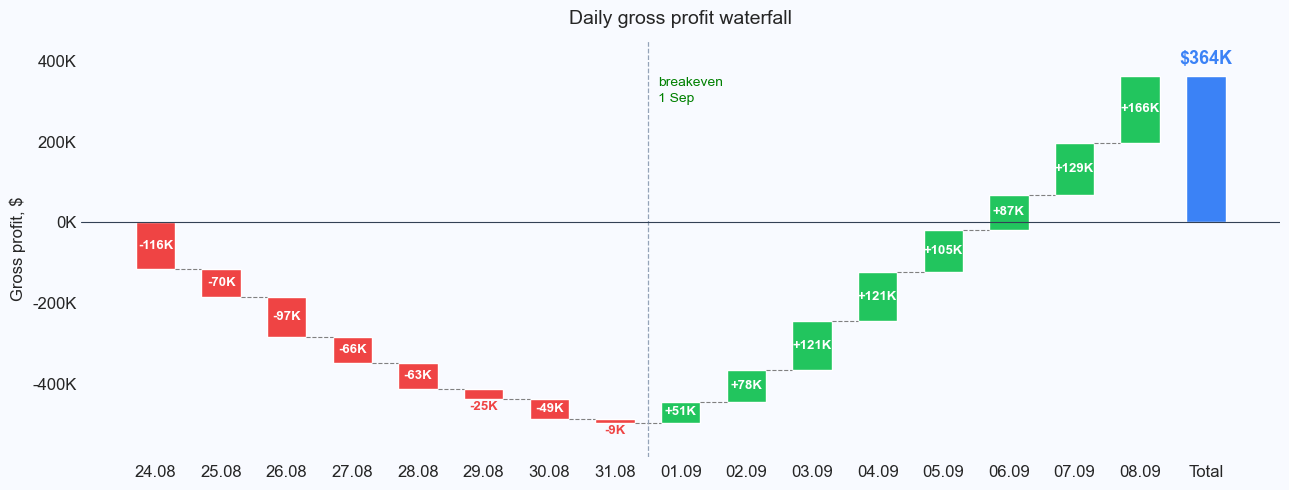

In [92]:


dates   = df_profit['month_day'].tolist()
# Scale to thousands for better readability
amounts = (df_profit['gross_profit'] / 1000).values

running = 0
bases, heights, colors, running_totals = [], [], [], []

# Calculate waterfall step positions
for amt in amounts:
    running_totals.append(running + amt)
    if amt >= 0:
        bases.append(running)
        heights.append(amt)
        colors.append('#22c55e')
    else:
        bases.append(running + amt)
        heights.append(abs(amt))
        colors.append('#ef4444')
    running += amt

total = running
all_labels = dates + ['Total']

# --- Figure Styling ---
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor('#f8faff')
ax.set_facecolor('#f8faff')

x = np.arange(len(all_labels))
ax.bar(x[:-1], heights, bottom=bases, color=colors, width=0.6, edgecolor='white')
ax.bar(x[-1], abs(total), bottom=0, color='#3b82f6', width=0.6, edgecolor='white')

# --- Connectors (Step Lines) ---
for i in range(len(amounts) - 1):
    y = running_totals[i]
    ax.plot([x[i] + 0.3, x[i+1] - 0.3], [y, y],
            color='gray', linewidth=0.8, linestyle='--')

# --- Value Labels ---
for i, (amt, h, b) in enumerate(zip(amounts, heights, bases)):
    label = f'{amt:+.0f}K'
    if h >= 35:
        ax.text(x[i], b + h/2, label, ha='center', va='center',
                fontsize=9.5, fontweight='bold', color='white')
    elif amt >= 0:
        ax.text(x[i], b + h + 5, label, ha='center', va='bottom',
                fontsize=9.5, color='#22c55e', fontweight='bold')
    else:
        ax.text(x[i], b - 5, label, ha='center', va='top',
                fontsize=9.5, color='#ef4444', fontweight='bold')

# Total value above the final blue bar
ax.text(x[-1], abs(total) + 18, f'${total:,.0f}K',
        ha='center', va='bottom',
        fontsize=13, fontweight='bold', color='#3b82f6')

# breakeven
breakeven_x = x[8] - 0.5
ax.axvline(breakeven_x, color='#94a3b8', linewidth=0.9, linestyle='--')
ax.text(breakeven_x + 0.15, 360, 'breakeven\n1 Sep',
        fontsize=10, color='green',
        ha='left', va='top', linespacing=1.4)

ax.axhline(0, color='#334155', linewidth=0.8)

# --- Final Layout Cleanup ---
ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=12)
ax.tick_params(axis='x', length=0, pad=6)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(-580, 450)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}K'))

for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)

ax.set_title('Daily gross profit waterfall',
             fontsize=14, pad=12)
ax.set_ylabel('Gross profit, $', fontsize=12)
ax.grid(False)
plt.tight_layout()

plt.show()

**Insight:** The waterfall shows the cumulative path from daily loss (Aug 24: −$116K) to profitability. Sep 1 was the turning point. Total net profit over the full period: **$364K**.